# Extended source models

This tutorial mirrors the binary-model walkthrough style, but focuses on the non-binary source extensions in `drpangloss`: `GaussianDiskModel`, `UniformDiskModel`, `ModulatedGaussianRimModel`, and `HarmonixModel`.

We'll build synthetic interferometric observables from a resolved Gaussian disk, pass them through `OIData`, then do the same for a uniform disk and an azimuthally modulated rim, and finally wrap a harmonix-style external source object to show how the visibility and rendering interfaces fit together.

In [1]:
import sys
from pathlib import Path

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from drpangloss.models import (
    GaussianDiskModel,
    HarmonixModel,
    ModulatedGaussianRimModel,
    UniformDiskModel,
)
from drpangloss.oidata import OIData

## Simulate resolved-disk observables

As with the binary examples, we start from a simple baseline geometry, instantiate a source model, and evaluate complex visibilities on those baselines.


In [2]:
rng = np.random.default_rng(7)
n_bl = 32
u = jnp.array(rng.uniform(-24.0, 24.0, size=n_bl))
v = jnp.array(rng.uniform(-24.0, 24.0, size=n_bl))
wavel = jnp.full((n_bl,), 1.65e-6)

truth = {"sigma": 18.0, "flux": 0.15, "dra": 12.0, "ddec": -7.5}
disk = GaussianDiskModel(**truth)
cvis_true = disk.model(u, v, wavel)

vis_true = jnp.abs(cvis_true) ** 2
phi_true = jnp.rad2deg(jnp.angle(cvis_true))

vis_scale = jnp.maximum(jnp.median(vis_true), 1e-6)
phi_scale = jnp.maximum(jnp.median(jnp.abs(phi_true)), 5.0)
d_vis = 0.01 * vis_scale * jnp.ones_like(vis_true)
d_phi = 0.02 * phi_scale * jnp.ones_like(phi_true)

vis_obs = vis_true + d_vis * jnp.array(rng.normal(size=vis_true.shape))
phi_obs = phi_true + d_phi * jnp.array(rng.normal(size=phi_true.shape))

data = OIData({
    "u": u,
    "v": v,
    "wavel": wavel,
    "vis": vis_obs,
    "d_vis": d_vis,
    "phi": phi_obs,
    "d_phi": d_phi,
    "i_cps1": None,
    "i_cps2": None,
    "i_cps3": None,
    "v2_flag": True,
    "cp_flag": False,
})

{
    "n_baselines": int(n_bl),
    "sigma_mas": truth["sigma"],
    "flux": truth["flux"],
    "centroid_mas": (truth["dra"], truth["ddec"]),
    "vis_range": (float(jnp.min(vis_true)), float(jnp.max(vis_true))),
}

{'n_baselines': 32,
 'sigma_mas': 18.0,
 'flux': 0.15,
 'centroid_mas': (12.0, -7.5),
 'vis_range': (0.7543691396713257, 0.8830579519271851)}

## Use `OIData` to flatten observables

`OIData.model(...)` evaluates the source model, converts complex visibilities to the configured observables, and flattens the result into a vector that can be compared directly to the measured data.


In [3]:
model_vec = data.model(disk)
data_vec, err_vec = data.flatten_data()

{
    "model_len": int(model_vec.shape[0]),
    "data_len": int(data_vec.shape[0]),
    "error_len": int(err_vec.shape[0]),
    "vector_alignment": bool(
        model_vec.shape == data_vec.shape == err_vec.shape
    ),
}

{'model_len': 64, 'data_len': 64, 'error_len': 64, 'vector_alignment': True}

## Visualize the Gaussian disk in Fourier and image space

A resolved Gaussian disk has visibility amplitudes that fall smoothly with baseline length. The new `render(...)` method gives a matching image-plane representation for plotting and sanity checks.


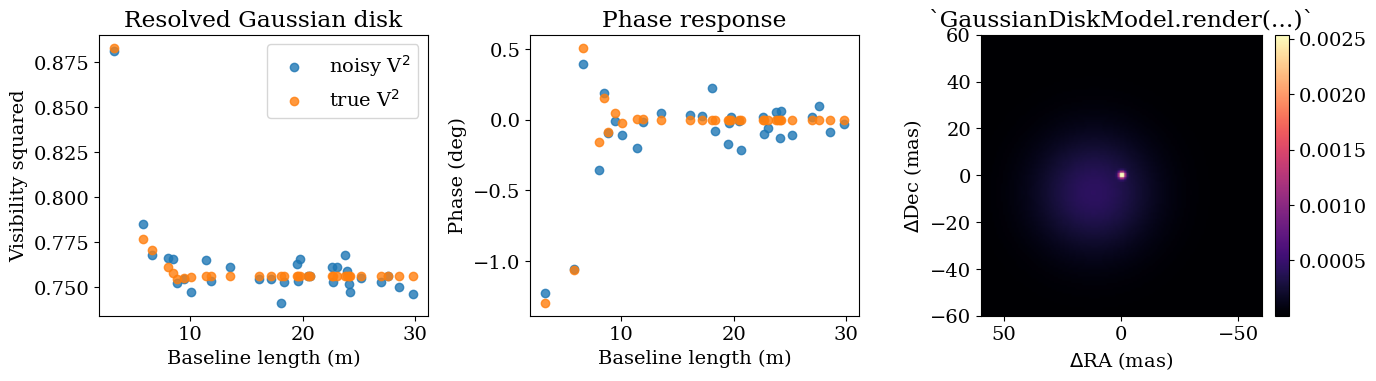

In [4]:
baseline = np.sqrt(np.asarray(u) ** 2 + np.asarray(v) ** 2)
image = np.asarray(disk.render(npix=128, fov_mas=120.0))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(baseline, np.asarray(vis_obs), alpha=0.8, label="noisy V$^2$")
axes[0].scatter(baseline, np.asarray(vis_true), alpha=0.8, label="true V$^2$")
axes[0].set_xlabel("Baseline length (m)")
axes[0].set_ylabel("Visibility squared")
axes[0].set_title("Resolved Gaussian disk")
axes[0].legend(loc="best")

axes[1].scatter(baseline, np.asarray(phi_obs), alpha=0.8, label="noisy phase")
axes[1].scatter(baseline, np.asarray(phi_true), alpha=0.8, label="true phase")
axes[1].set_xlabel("Baseline length (m)")
axes[1].set_ylabel("Phase (deg)")
axes[1].set_title("Phase response")

im = axes[2].imshow(
    image,
    extent=[60.0, -60.0, -60.0, 60.0],
    cmap="magma",
)
axes[2].set_xlabel(r"$\Delta$RA (mas)")
axes[2].set_ylabel(r"$\Delta$Dec (mas)")
axes[2].set_title("`GaussianDiskModel.render(...)`")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Wrap a harmonix-style external source

`HarmonixModel` is the bridge between `drpangloss` and external source objects that already know how to evaluate visibilities. In the real package this can wrap a harmonix source with a `model(u, v, t)` method. Here we use a compact toy object with the same calling convention so the data flow is completely explicit.


In [5]:
class ToySurface:
    def render(self, res, theta):
        coords = jnp.linspace(-1.0, 1.0, res)
        xx, yy = jnp.meshgrid(coords, coords, indexing="xy")
        c, s = jnp.cos(theta), jnp.sin(theta)
        xr = c * xx + s * yy
        yr = -s * xx + c * yy
        image = jnp.exp(-0.5 * ((xr / 0.35) ** 2 + (yr / 0.18) ** 2))
        return image / jnp.sum(image)


class ToyHarmonixSource:
    def __init__(self):
        self.surface = ToySurface()

    def rotational_phase(self, time):
        return 2.0 * jnp.pi * time

    def model(self, uu, vv, time):
        rho = jnp.sqrt((uu / 8.0e7) ** 2 + (vv / 5.0e7) ** 2)
        envelope = jnp.exp(-(rho**2))
        phase = jnp.exp(-2j * jnp.pi * time * uu / 2.0e8)
        return envelope * phase


wrapped = HarmonixModel(ToyHarmonixSource(), observation_time=0.2)
cvis_ext = wrapped.model(u, v, wavel)
image_ext = np.asarray(wrapped.render(npix=128, fov_mas=40.0))

{
    "cvis_shape": tuple(cvis_ext.shape),
    "all_finite": bool(jnp.all(jnp.isfinite(cvis_ext))),
    "render_sum": float(np.sum(image_ext)),
}

{'cvis_shape': (32,), 'all_finite': True, 'render_sum': 1.0}

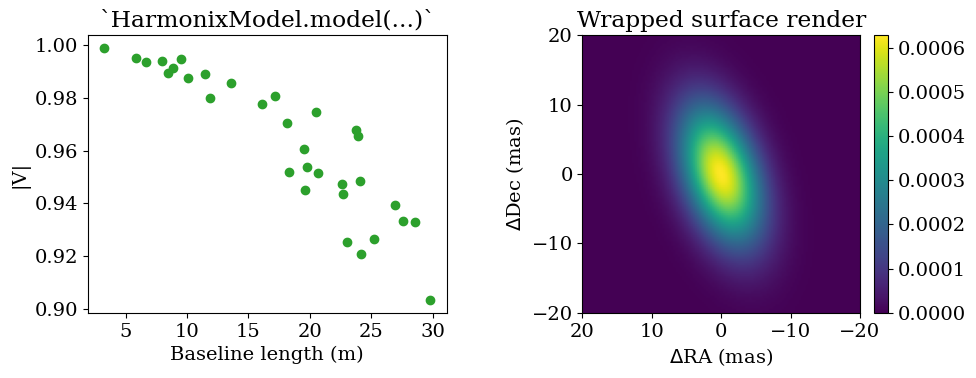

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(baseline, np.asarray(jnp.abs(cvis_ext)), color="tab:green")
axes[0].set_xlabel("Baseline length (m)")
axes[0].set_ylabel("|V|")
axes[0].set_title("`HarmonixModel.model(...)`")

im = axes[1].imshow(
    image_ext,
    extent=[20.0, -20.0, -20.0, 20.0],
    cmap="viridis",
)
axes[1].set_xlabel(r"$\Delta$RA (mas)")
axes[1].set_ylabel(r"$\Delta$Dec (mas)")
axes[1].set_title("Wrapped surface render")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

This is the same pattern you would use with a real harmonix object: instantiate the external source, wrap it in `HarmonixModel`, and then call `model(...)` or `render(...)` through the common `SourceModel` interface.


## Simulate a uniform-disk companion

`UniformDiskModel` represents a resolved tophat (uniform-brightness) disk. Unlike `GaussianDiskModel`, it has no `flux`/point-source mixture -- the whole model is the resolved disk. Its visibility amplitude follows the classic Airy pattern `2*J1(x)/x`.

In [7]:
udisk = UniformDiskModel(ud=25.0, dra=-9.0, ddec=6.0)
cvis_udisk = udisk.model(u, v, wavel)

vis_udisk = jnp.abs(cvis_udisk) ** 2
phi_udisk = jnp.rad2deg(jnp.angle(cvis_udisk))
model_vec_udisk = data.model(udisk)

{
    "ud_mas": float(udisk.ud),
    "centroid_mas": (float(udisk.dra), float(udisk.ddec)),
    "vis_range": (float(jnp.min(vis_udisk)), float(jnp.max(vis_udisk))),
    "model_len": int(model_vec_udisk.shape[0]),
}

{'ud_mas': 25.0,
 'centroid_mas': (-9.0, 6.0),
 'vis_range': (0.00014090703916735947, 0.8681560754776001),
 'model_len': 64}

## Visualize the uniform disk in Fourier and image space

Visibility squared falls off with Airy-like nulls as baseline length grows; `render(...)` gives the matching tophat image.

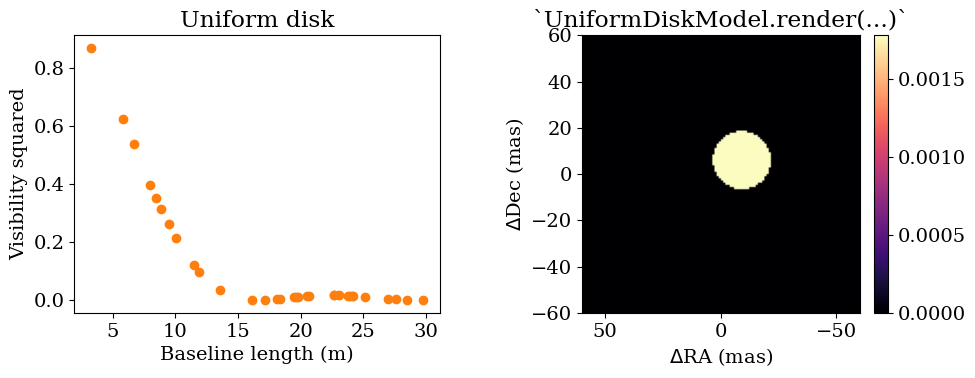

In [8]:
image_udisk = np.asarray(udisk.render(npix=128, fov_mas=120.0))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(baseline, np.asarray(vis_udisk), color="tab:orange")
axes[0].set_xlabel("Baseline length (m)")
axes[0].set_ylabel("Visibility squared")
axes[0].set_title("Uniform disk")

im = axes[1].imshow(
    image_udisk,
    extent=[60.0, -60.0, -60.0, 60.0],
    cmap="magma",
)
axes[1].set_xlabel(r"$\Delta$RA (mas)")
axes[1].set_ylabel(r"$\Delta$Dec (mas)")
axes[1].set_title("`UniformDiskModel.render(...)`")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Simulate an azimuthally modulated rim

`ModulatedGaussianRimModel` is an inclined, Gaussian-blurred ring mixed with an unresolved point source (the same `flux` companion/star convention as `GaussianDiskModel`), optionally modulated azimuthally with a sum of cosine terms (`az_amps`/`az_pas`). We compare a symmetric rim against one with a single first-order modulation.

In [9]:
rim_symmetric = ModulatedGaussianRimModel(
    diam=14.15,
    fwhm=3.233,
    inc=19.0,
    pa=6.0,
    flux=0.67504187604,
    az_amps=jnp.array([0.0]),
    az_pas=jnp.array([0.0]),
)
rim_modulated = ModulatedGaussianRimModel(
    diam=14.15,
    fwhm=3.233,
    inc=19.0,
    pa=6.0,
    flux=0.67504187604,
    az_amps=jnp.array([0.43011627, 0.2745906]),
    az_pas=jnp.array([35.537678 + 6.0, 50.245735 + 6.0]),
)

cvis_rim = rim_modulated.model(u, v, wavel)
vis_rim = jnp.abs(cvis_rim) ** 2
phi_rim = jnp.rad2deg(jnp.angle(cvis_rim))
model_vec_rim = data.model(rim_modulated)

{
    "diam_mas": float(rim_modulated.diam),
    "flux": float(rim_modulated.flux),
    "az_amps": np.asarray(rim_modulated.az_amps).tolist(),
    "az_pas_deg": np.asarray(rim_modulated.az_pas).tolist(),
    "model_len": int(model_vec_rim.shape[0]),
}

{'diam_mas': 14.149999618530273,
 'flux': 0.6750418543815613,
 'az_amps': [0.4301162660121918, 0.2745906114578247],
 'az_pas_deg': [41.53767776489258, 56.24573516845703],
 'model_len': 64}

## Visualize the rim: azimuthal modulation and Fourier response

Rendering both variants side by side shows how `az_amps`/`az_pas` breaks the ring's azimuthal symmetry; the visibility-squared panel shows the modulated rim's (`flux`-mixed) Fourier response. The parameters are chosen here so the modulated rim model and its image
match the final geometric model shown for the post-AGB IRAS 08544-4431 in [Hillen et al. 2016](http://dx.doi.org/10.1051/0004-6361/201628125).

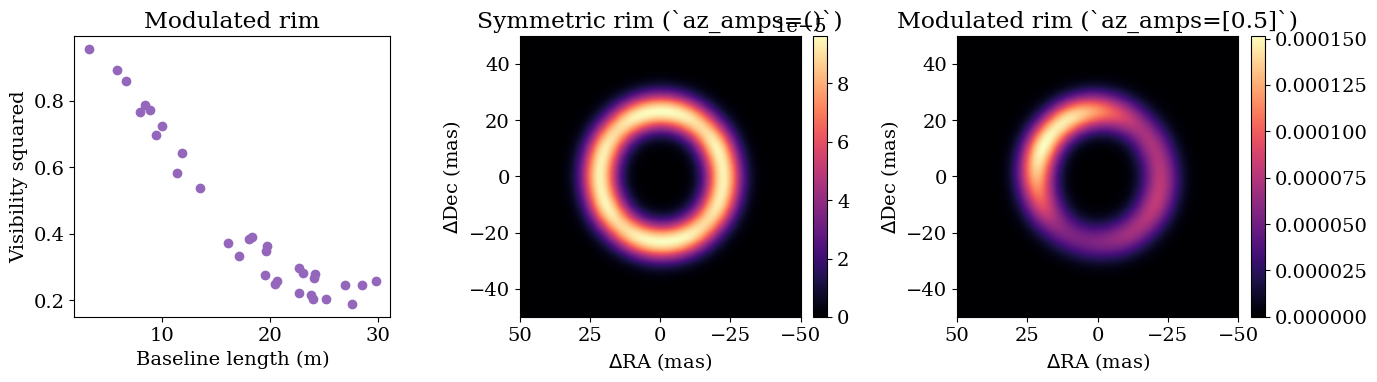

In [10]:
image_rim_symmetric = np.asarray(rim_symmetric.render(npix=256, fov_mas=30.0))
image_rim_modulated = np.asarray(rim_modulated.render(npix=256, fov_mas=30.0))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(baseline, np.asarray(vis_rim), color="tab:purple")
axes[0].set_xlabel("Baseline length (m)")
axes[0].set_ylabel("Visibility squared")
axes[0].set_title("Modulated rim")

im1 = axes[1].imshow(
    image_rim_symmetric,
    extent=[50.0, -50.0, -50.0, 50.0],
    cmap="magma",
)
axes[1].set_xlabel(r"$\Delta$RA (mas)")
axes[1].set_ylabel(r"$\Delta$Dec (mas)")
axes[1].set_title("Symmetric rim (`az_amps=()`)")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(
    image_rim_modulated,
    extent=[50.0, -50.0, -50.0, 50.0],
    cmap="magma",
)
axes[2].set_xlabel(r"$\Delta$RA (mas)")
axes[2].set_ylabel(r"$\Delta$Dec (mas)")
axes[2].set_title("Modulated rim (`az_amps=[0.5]`)")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()